In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

PROJECT_DIR = '/content/drive/MyDrive/gpr_fwi_diffusion'
os.chdir(PROJECT_DIR)
print("Working directory:", os.getcwd())
print("Files in Drive:", os.listdir(PROJECT_DIR))

Mounted at /content/drive
Working directory: /content/drive/MyDrive/gpr_fwi_diffusion
Files in Drive: ['groundtruth.png', 'observed_data.png', 'obs_data.npy', 'trace_cols.npy', 'gpr_synthetic_dataset.pt', 'loss_history.pt', 'diffusion_unet_weights.pt', 'loss_curves.npy', 'all_metrics.npy', 'inversion_results.npy', 'obs_data_hard.npy', 'trace_cols_hard.npy', 'inversion_results_hard.npy', 'all_metrics_hard.npy', 'figure5_comparison_preview.png', 'obs_data_v2.npy', 'trace_cols_v2.npy', 'all_metrics_v2.npy', 'inversion_results_v2.npy', 'obs_data_v3.npy', 'trace_cols_v3.npy', 'eps_true.npy', 'sig_true.npy', 'figure5_comparison_v3.png', 'inversion_results_v3.npy', 'figure5_comparison_400iter.png', 'all_metrics_v3.npy', 'figure5_final.png', 'eps_dry.npy', 'sig_dry.npy', 'eps_water.npy', 'sig_water.npy', 'eps_napl.npy', 'sig_napl.npy', 'obs_dry.npy', 'tc_dry.npy', 'obs_water.npy', 'tc_water.npy', 'obs_napl.npy', 'tc_napl.npy', 'eps_rec_dry.npy', 'sig_rec_dry.npy', 'eps_rec_water.npy', 'sig_rec

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

EPS_MIN, EPS_MAX = 2.0, 25.0
SIG_MIN, SIG_MAX = 0.0001, 0.05

def normalize(x, lo, hi):
    return 2 * (np.clip(x, lo, hi) - lo) / (hi - lo) - 1

def denormalize(x, lo, hi):
    return (x + 1) / 2 * (hi - lo) + lo

class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb = t[:, None].float() * emb[None, :]
        return torch.cat([emb.sin(), emb.cos()], dim=-1)

class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)
        self.block1 = nn.Sequential(
            nn.GroupNorm(8, in_ch), nn.SiLU(),
            nn.Conv2d(in_ch, out_ch, 3, padding=1))
        self.block2 = nn.Sequential(
            nn.GroupNorm(8, out_ch), nn.SiLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1))
        self.res_conv = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x, t_emb):
        h = self.block1(x)
        h = h + self.time_mlp(t_emb)[:, :, None, None]
        h = self.block2(h)
        return h + self.res_conv(x)

class SimpleUNet(nn.Module):
    def __init__(self, in_ch=2, base_ch=64, time_emb_dim=128):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim), nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim))
        self.in_conv = nn.Conv2d(in_ch, base_ch, 3, padding=1)
        self.down1 = ResidualBlock(base_ch, base_ch, time_emb_dim)
        self.pool1 = nn.Conv2d(base_ch, base_ch, 4, stride=2, padding=1)
        self.down2 = ResidualBlock(base_ch, base_ch*2, time_emb_dim)
        self.pool2 = nn.Conv2d(base_ch*2, base_ch*2, 4, stride=2, padding=1)
        self.down3 = ResidualBlock(base_ch*2, base_ch*4, time_emb_dim)
        self.pool3 = nn.Conv2d(base_ch*4, base_ch*4, 4, stride=2, padding=1)
        self.bottleneck = ResidualBlock(base_ch*4, base_ch*4, time_emb_dim)
        self.up3 = nn.ConvTranspose2d(base_ch*4, base_ch*4, 4, stride=2, padding=1)
        self.dec3 = ResidualBlock(base_ch*8, base_ch*2, time_emb_dim)
        self.up2 = nn.ConvTranspose2d(base_ch*2, base_ch*2, 4, stride=2, padding=1)
        self.dec2 = ResidualBlock(base_ch*4, base_ch, time_emb_dim)
        self.up1 = nn.ConvTranspose2d(base_ch, base_ch, 4, stride=2, padding=1)
        self.dec1 = ResidualBlock(base_ch*2, base_ch, time_emb_dim)
        self.out_conv = nn.Sequential(
            nn.GroupNorm(8, base_ch), nn.SiLU(),
            nn.Conv2d(base_ch, in_ch, 3, padding=1))
    def forward(self, x, t):
        t_emb = self.time_mlp(t)
        x0 = self.in_conv(x)
        d1 = self.down1(x0, t_emb)
        d2 = self.down2(self.pool1(d1), t_emb)
        d3 = self.down3(self.pool2(d2), t_emb)
        b  = self.bottleneck(self.pool3(d3), t_emb)
        u3 = self.dec3(torch.cat([self.up3(b),  d3], dim=1), t_emb)
        u2 = self.dec2(torch.cat([self.up2(u3), d2], dim=1), t_emb)
        u1 = self.dec1(torch.cat([self.up1(u2), d1], dim=1), t_emb)
        return self.out_conv(u1)

class DiffusionSchedule:
    def __init__(self, timesteps=1000, beta_start=1e-4, beta_end=0.02, device='cuda'):
        self.timesteps = timesteps
        self.betas = torch.linspace(beta_start, beta_end, timesteps, device=device)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)
    def q_sample(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)
        sqrt_ac   = self.sqrt_alphas_cumprod[t][:, None, None, None]
        sqrt_omac = self.sqrt_one_minus_alphas_cumprod[t][:, None, None, None]
        return sqrt_ac * x0 + sqrt_omac * noise

model    = SimpleUNet().to(device)
schedule = DiffusionSchedule(timesteps=1000, device=device)
model.load_state_dict(torch.load('diffusion_unet_weights.pt', map_location=device))
model.eval()
print("Diffusion model loaded.")

def forward_model(eps, sig, n_traces=32, noise_level=0.0):
    H, W = eps.shape
    t = np.linspace(-1, 1, 21)
    f0 = 0.3
    wavelet    = (1 - 2*(np.pi*f0*t)**2) * np.exp(-(np.pi*f0*t)**2)
    trace_cols = np.linspace(0, W-1, n_traces, dtype=int)
    data       = np.zeros((n_traces, H), dtype=np.float32)
    for i, col in enumerate(trace_cols):
        impedance   = 1.0 / np.sqrt(eps[:, col])
        refl        = np.diff(impedance, prepend=impedance[0])
        attenuation = np.exp(-np.cumsum(sig[:, col]) * 2.0)
        data[i]     = np.convolve(refl * attenuation, wavelet, mode='same')
    if noise_level > 0:
        data += noise_level * np.std(data) * np.random.randn(*data.shape)
    return data.astype(np.float32), trace_cols

def compute_gradient(eps, sig, obs_data, trace_cols):
    H, W      = eps.shape
    t         = np.linspace(-1, 1, 21)
    f0        = 0.3
    wavelet   = (1 - 2*(np.pi*f0*t)**2) * np.exp(-(np.pi*f0*t)**2)
    pred_data = forward_model(eps, sig, n_traces=len(trace_cols))[0]
    residual  = pred_data - obs_data
    misfit    = 0.5 * np.sum(residual**2)
    grad_eps  = np.zeros_like(eps)
    grad_sig  = np.zeros_like(sig)
    for i, col in enumerate(trace_cols):
        adj         = np.convolve(residual[i], wavelet[::-1], mode='same')
        attenuation = np.exp(-np.cumsum(sig[:, col]) * 2.0)
        d_imp_d_eps = -0.5 / (eps[:, col]**1.5)
        for d in range(H):
            grad_eps[d, col] += adj[d] * attenuation[d] * d_imp_d_eps[d]
        for d in range(H):
            grad_sig[d, col] += -2.0 * adj[d] * attenuation[d] * \
                                  np.sum(adj[:d+1])
    return grad_eps, grad_sig, misfit

@torch.no_grad()
def diffusion_project_gentle(eps_arr, sig_arr, t_start=50):
    eps_n = normalize(eps_arr, EPS_MIN, EPS_MAX)
    sig_n = normalize(sig_arr, SIG_MIN, SIG_MAX)
    x0    = torch.from_numpy(
        np.stack([eps_n, sig_n], axis=0)[None]).float().to(device)
    t_tensor = torch.tensor([t_start], device=device)
    x        = schedule.q_sample(x0, t_tensor, torch.randn_like(x0))
    for t_cur in reversed(range(0, t_start)):
        t_cur_tensor = torch.tensor([t_cur], device=device)
        beta_t    = schedule.betas[t_cur]
        alpha_t   = schedule.alphas[t_cur]
        alpha_bar = schedule.alphas_cumprod[t_cur]
        pred_noise = model(x, t_cur_tensor)
        if t_cur > 0:
            coef = beta_t / torch.sqrt(1 - alpha_bar)
            x    = (1 / torch.sqrt(alpha_t)) * (x - coef * pred_noise)
        else:
            x = (x - torch.sqrt(1 - alpha_bar) * pred_noise) / \
                 torch.sqrt(alpha_bar)
            x = torch.clamp(x, -1, 1)
    x_d     = x.squeeze(0).cpu().numpy()
    eps_den = np.clip(denormalize(x_d[0], EPS_MIN, EPS_MAX), EPS_MIN, EPS_MAX)
    sig_den = np.clip(denormalize(x_d[1], SIG_MIN, SIG_MAX), SIG_MIN, SIG_MAX)
    return eps_den, sig_den

from skimage.metrics import structural_similarity as skssim
def compute_metrics(recon, true):
    rmse     = np.sqrt(np.mean((recon - true)**2))
    ssim_val = skssim(true, recon, data_range=true.max() - true.min())
    return rmse, ssim_val

# Load existing ground truths
eps_water = np.load('eps_water.npy'); sig_water = np.load('sig_water.npy')
eps_napl  = np.load('eps_napl.npy');  sig_napl  = np.load('sig_napl.npy')
obs_water = np.load('obs_water.npy'); tc_water  = np.load('tc_water.npy')
obs_napl  = np.load('obs_napl.npy');  tc_napl   = np.load('tc_napl.npy')

print("All definitions ready. Ground truths and observed data loaded.")

Device: cuda
Diffusion model loaded.
All definitions ready. Ground truths and observed data loaded.


In [3]:
def run_single_inversion(obs_data, trace_cols, seed, n_iter=400):
    """Single diffusion-regularized inversion run with a fixed random seed,
    controlling both numpy (data ordering not used here, but kept for
    consistency) and torch (controls the stochastic noise in q_sample
    inside diffusion_project_gentle -- this is the actual source of
    ensemble diversity)."""
    np.random.seed(seed)
    torch.manual_seed(seed)

    eps_init = np.full((64, 64), 4.0,   dtype=np.float32)
    sig_init = np.full((64, 64), 0.001, dtype=np.float32)
    eps_init[56:, :] = 8.0
    sig_init[56:, :] = 0.01

    eps, sig = eps_init.copy(), sig_init.copy()
    LR_EPS, LR_SIG, BLEND = 0.05, 0.0001, 0.08

    for it in range(n_iter):
        grad_e, grad_s, misfit = compute_gradient(eps, sig, obs_data, trace_cols)
        eps = np.clip(eps - LR_EPS * grad_e, EPS_MIN, EPS_MAX)
        sig = np.clip(sig - LR_SIG * grad_s, SIG_MIN, SIG_MAX)
        if it % 5 == 0:
            eps_den, sig_den = diffusion_project_gentle(eps, sig, t_start=50)
            eps = np.clip((1-BLEND)*eps + BLEND*eps_den, EPS_MIN, EPS_MAX)
            sig = np.clip((1-BLEND)*sig + BLEND*sig_den, SIG_MIN, SIG_MAX)
    return eps, sig


N_ENSEMBLE = 10
ensemble_eps = []
ensemble_sig = []

print(f"Running {N_ENSEMBLE}-member ensemble on Water state...")
for i in range(N_ENSEMBLE):
    eps_i, sig_i = run_single_inversion(obs_water, tc_water, seed=100+i, n_iter=400)
    ensemble_eps.append(eps_i)
    ensemble_sig.append(sig_i)
    re, se = compute_metrics(eps_i, eps_water)
    print(f"  Run {i+1}/{N_ENSEMBLE} (seed={100+i}): eps_r RMSE={re:.4f} SSIM={se:.4f}")

ensemble_eps = np.stack(ensemble_eps)  # shape (10, 64, 64)
ensemble_sig = np.stack(ensemble_sig)

np.save('ensemble_eps_water.npy', ensemble_eps)
np.save('ensemble_sig_water.npy', ensemble_sig)
print("\nEnsemble saved to Drive.")

Running 10-member ensemble on Water state...
  Run 1/10 (seed=100): eps_r RMSE=5.7888 SSIM=0.7844
  Run 2/10 (seed=101): eps_r RMSE=5.8015 SSIM=0.7814
  Run 3/10 (seed=102): eps_r RMSE=5.8031 SSIM=0.7805
  Run 4/10 (seed=103): eps_r RMSE=5.8009 SSIM=0.7838
  Run 5/10 (seed=104): eps_r RMSE=5.8003 SSIM=0.7844
  Run 6/10 (seed=105): eps_r RMSE=5.7997 SSIM=0.7839
  Run 7/10 (seed=106): eps_r RMSE=5.8008 SSIM=0.7830
  Run 8/10 (seed=107): eps_r RMSE=5.8072 SSIM=0.7831
  Run 9/10 (seed=108): eps_r RMSE=5.7896 SSIM=0.7829
  Run 10/10 (seed=109): eps_r RMSE=5.8154 SSIM=0.7814

Ensemble saved to Drive.


eps_r std range: 0.00271 to 7.83850
sig std range: 0.000000 to 0.023231


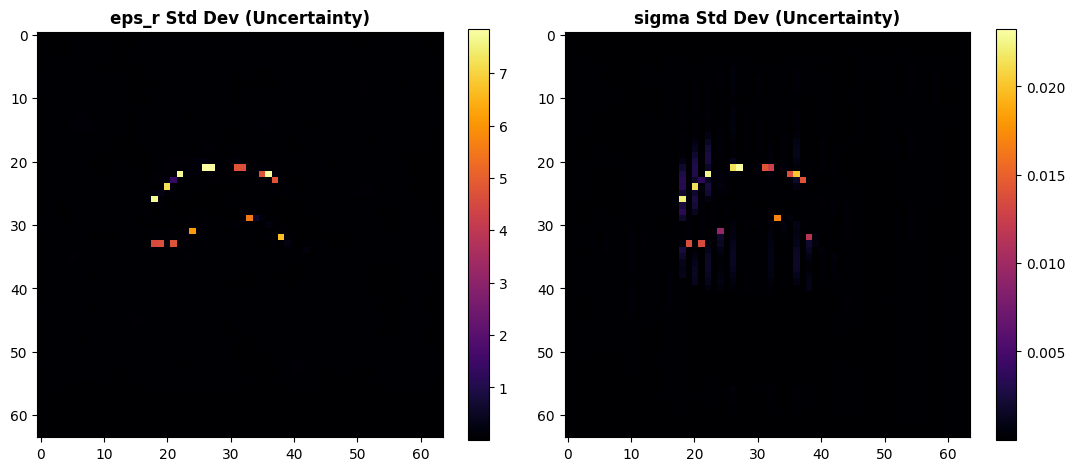

In [4]:
eps_mean = ensemble_eps.mean(axis=0)
eps_std  = ensemble_eps.std(axis=0)
sig_mean = ensemble_sig.mean(axis=0)
sig_std  = ensemble_sig.std(axis=0)

print(f"eps_r std range: {eps_std.min():.5f} to {eps_std.max():.5f}")
print(f"sig std range: {sig_std.min():.6f} to {sig_std.max():.6f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
im0 = axes[0].imshow(eps_std, cmap='inferno')
axes[0].set_title('eps_r Std Dev (Uncertainty)', fontweight='bold')
plt.colorbar(im0, ax=axes[0])
im1 = axes[1].imshow(sig_std, cmap='inferno')
axes[1].set_title('sigma Std Dev (Uncertainty)', fontweight='bold')
plt.colorbar(im1, ax=axes[1])
plt.tight_layout()
plt.show()

eps_r: correlation(std, |error|) = 0.0639
sigma: correlation(std, |error|) = 0.1260


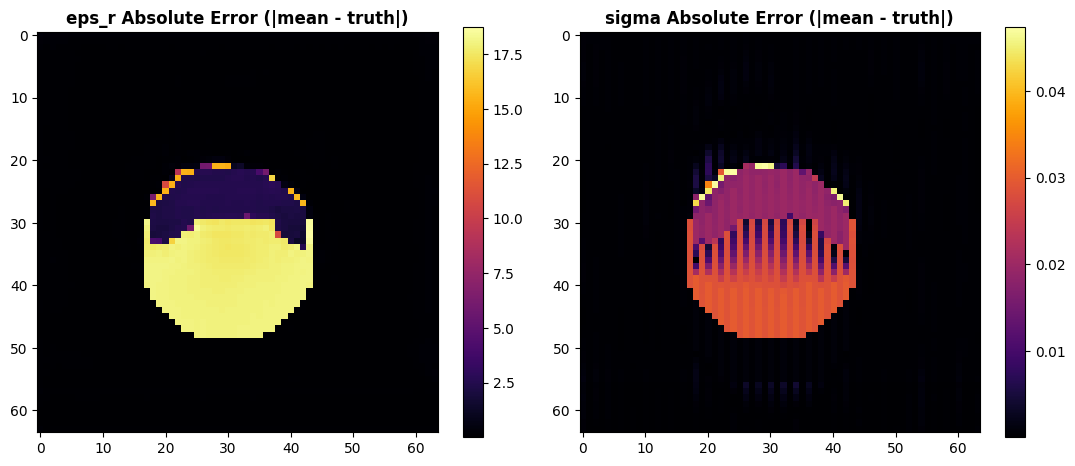

Mean/std maps saved to Drive.


In [5]:
eps_mean = ensemble_eps.mean(axis=0)
sig_mean = ensemble_sig.mean(axis=0)

eps_error = np.abs(eps_mean - eps_water)
sig_error = np.abs(sig_mean - sig_water)

# Correlation between uncertainty (std) and actual error
eps_corr = np.corrcoef(eps_std.flatten(), eps_error.flatten())[0, 1]
sig_corr = np.corrcoef(sig_std.flatten(), sig_error.flatten())[0, 1]

print(f"eps_r: correlation(std, |error|) = {eps_corr:.4f}")
print(f"sigma: correlation(std, |error|) = {sig_corr:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
im0 = axes[0].imshow(eps_error, cmap='inferno')
axes[0].set_title('eps_r Absolute Error (|mean - truth|)', fontweight='bold')
plt.colorbar(im0, ax=axes[0])
im1 = axes[1].imshow(sig_error, cmap='inferno')
axes[1].set_title('sigma Absolute Error (|mean - truth|)', fontweight='bold')
plt.colorbar(im1, ax=axes[1])
plt.tight_layout()
plt.show()

np.save('eps_mean_water.npy', eps_mean); np.save('eps_std_water.npy', eps_std)
np.save('sig_mean_water.npy', sig_mean); np.save('sig_std_water.npy', sig_std)
print("Mean/std maps saved to Drive.")

In [6]:
N_ENSEMBLE = 10
ensemble_eps_napl = []
ensemble_sig_napl = []

print(f"Running {N_ENSEMBLE}-member ensemble on NAPL state...")
for i in range(N_ENSEMBLE):
    eps_i, sig_i = run_single_inversion(obs_napl, tc_napl, seed=200+i, n_iter=250)
    ensemble_eps_napl.append(eps_i)
    ensemble_sig_napl.append(sig_i)
    re, se = compute_metrics(eps_i, eps_napl)
    print(f"  Run {i+1}/{N_ENSEMBLE} (seed={200+i}): eps_r RMSE={re:.4f} SSIM={se:.4f}")

ensemble_eps_napl = np.stack(ensemble_eps_napl)
ensemble_sig_napl = np.stack(ensemble_sig_napl)

eps_mean_napl = ensemble_eps_napl.mean(axis=0)
eps_std_napl  = ensemble_eps_napl.std(axis=0)
eps_error_napl = np.abs(eps_mean_napl - eps_napl)

corr_napl = np.corrcoef(eps_std_napl.flatten(), eps_error_napl.flatten())[0, 1]
print(f"\nNAPL eps_r: correlation(std, |error|) = {corr_napl:.4f}")

np.save('ensemble_eps_napl.npy', ensemble_eps_napl)
np.save('ensemble_sig_napl.npy', ensemble_sig_napl)
np.save('eps_mean_napl.npy', eps_mean_napl)
np.save('eps_std_napl.npy', eps_std_napl)
print("NAPL ensemble saved to Drive.")

Running 10-member ensemble on NAPL state...
  Run 1/10 (seed=200): eps_r RMSE=5.4076 SSIM=0.7059
  Run 2/10 (seed=201): eps_r RMSE=5.2963 SSIM=0.7143
  Run 3/10 (seed=202): eps_r RMSE=5.2936 SSIM=0.7125
  Run 4/10 (seed=203): eps_r RMSE=5.3285 SSIM=0.7097
  Run 5/10 (seed=204): eps_r RMSE=5.3354 SSIM=0.7087
  Run 6/10 (seed=205): eps_r RMSE=5.2896 SSIM=0.7127
  Run 7/10 (seed=206): eps_r RMSE=5.3328 SSIM=0.7120
  Run 8/10 (seed=207): eps_r RMSE=5.3138 SSIM=0.7110
  Run 9/10 (seed=208): eps_r RMSE=5.3892 SSIM=0.7080
  Run 10/10 (seed=209): eps_r RMSE=5.3275 SSIM=0.7100

NAPL eps_r: correlation(std, |error|) = 0.1924
NAPL ensemble saved to Drive.


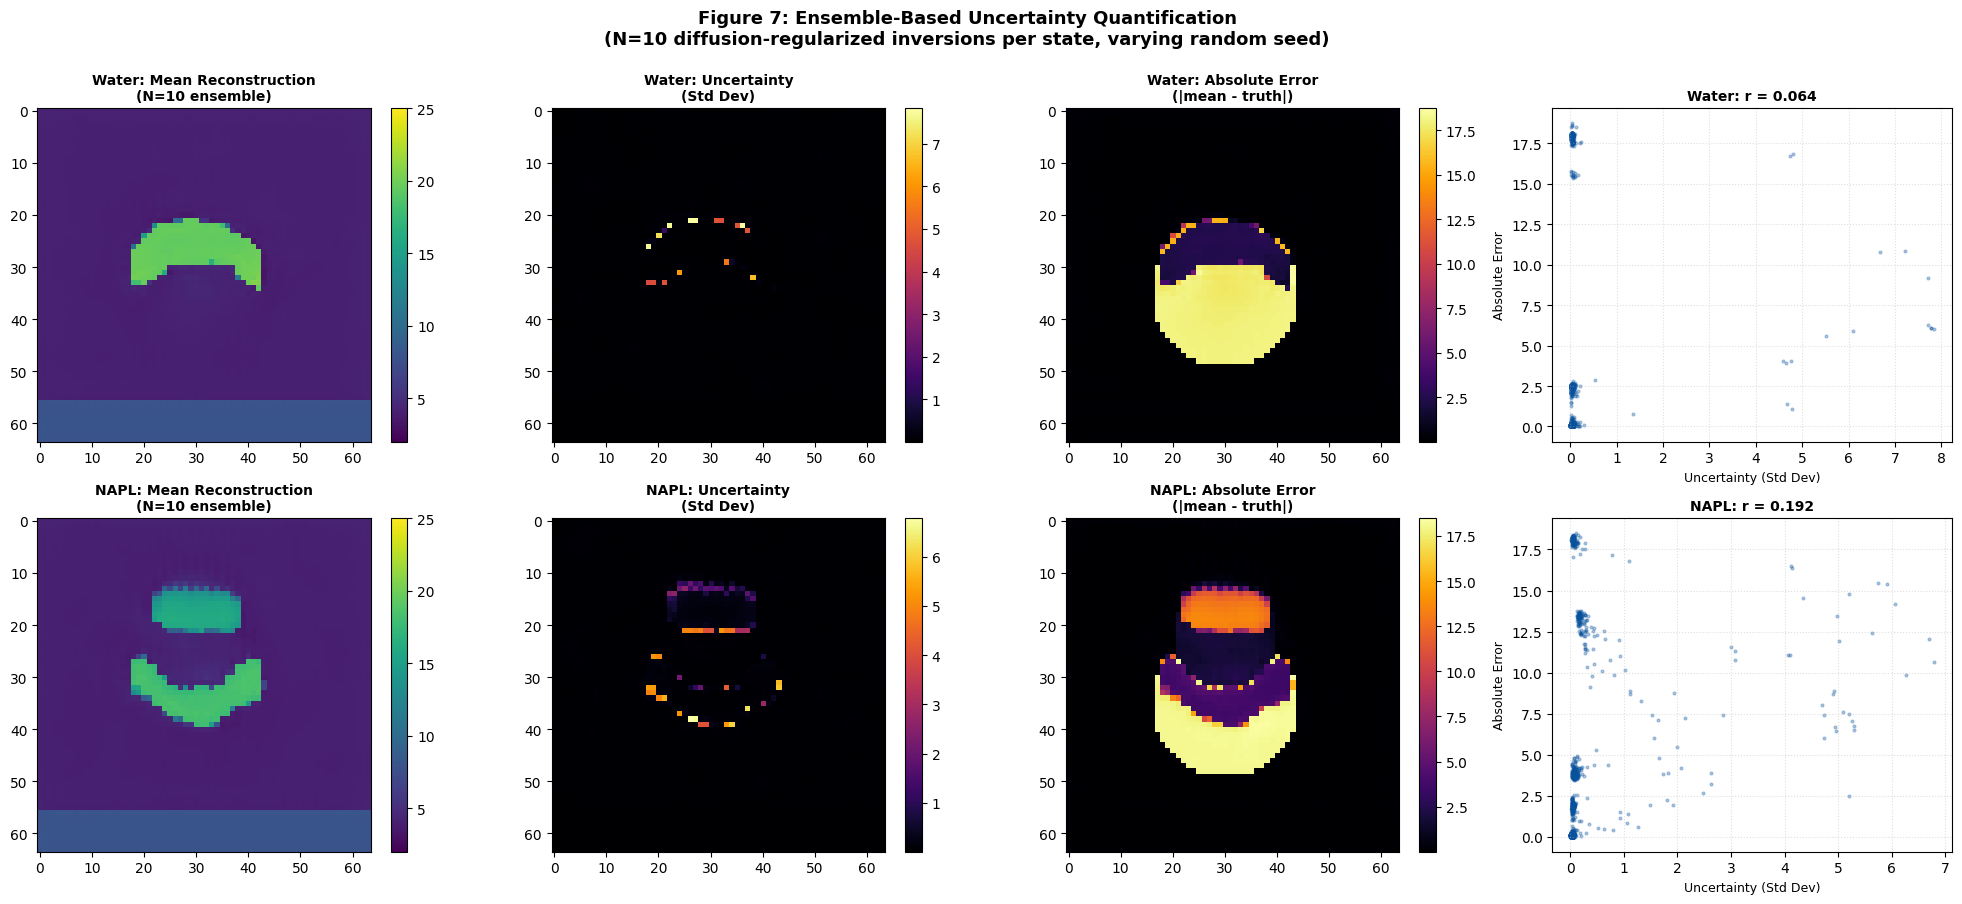

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Figure 7 saved at 300 dpi.


In [7]:
sig_mean_napl = ensemble_sig_napl.mean(axis=0)
sig_std_napl  = ensemble_sig_napl.std(axis=0)

fig, axes = plt.subplots(2, 4, figsize=(20, 9))

row_data = [
    ('Water', eps_mean, eps_std, eps_water, eps_error, eps_corr),
    ('NAPL',  eps_mean_napl, eps_std_napl, eps_napl, eps_error_napl, corr_napl),
]

for i, (name, mean_r, std_r, truth, err, corr) in enumerate(row_data):
    im0 = axes[i, 0].imshow(mean_r, cmap='viridis', vmin=2, vmax=25)
    axes[i, 0].set_title(f'{name}: Mean Reconstruction\n(N=10 ensemble)',
                          fontsize=10, fontweight='bold')
    plt.colorbar(im0, ax=axes[i, 0], fraction=0.046)

    im1 = axes[i, 1].imshow(std_r, cmap='inferno')
    axes[i, 1].set_title(f'{name}: Uncertainty\n(Std Dev)',
                          fontsize=10, fontweight='bold')
    plt.colorbar(im1, ax=axes[i, 1], fraction=0.046)

    im2 = axes[i, 2].imshow(err, cmap='inferno')
    axes[i, 2].set_title(f'{name}: Absolute Error\n(|mean - truth|)',
                          fontsize=10, fontweight='bold')
    plt.colorbar(im2, ax=axes[i, 2], fraction=0.046)

    axes[i, 3].scatter(std_r.flatten(), err.flatten(), s=4, alpha=0.3,
                        color='#08519c')
    axes[i, 3].set_xlabel('Uncertainty (Std Dev)', fontsize=9)
    axes[i, 3].set_ylabel('Absolute Error', fontsize=9)
    axes[i, 3].set_title(f'{name}: r = {corr:.3f}', fontsize=10, fontweight='bold')
    axes[i, 3].grid(True, linestyle=':', alpha=0.4)

fig.suptitle('Figure 7: Ensemble-Based Uncertainty Quantification\n'
             '(N=10 diffusion-regularized inversions per state, varying random seed)',
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('figure7_uncertainty_final.png', dpi=300, bbox_inches='tight')
plt.show()

from google.colab import files
files.download('figure7_uncertainty_final.png')
print("Figure 7 saved at 300 dpi.")